In [17]:
import sys
import importlib

sys.path.append("..")
sys.path.append("../pretraining_compare_detectors")

import conf
importlib.reload(conf)

import core.QuadtreeWSIPairDataset
importlib.reload(core.QuadtreeWSIPairDataset)
from core.QuadtreeWSIPairDataset import QuadtreeWSIPairDataset

import keypoint_detectors
importlib.reload(keypoint_detectors)
from keypoint_detectors import SuperPointDetector

import numpy as np
import matplotlib.pyplot as plt

dataset = QuadtreeWSIPairDataset(
    annotation_path=conf.ANNOTATION_PATH,
    input_height=conf.CNN_INPUT_HEIGHT,
    input_width=conf.CNN_INPUT_WIDTH,
)

unique_pair_ids = sorted({job["pair_id"] for job in dataset.tile_jobs})
print(f"Dataset: {len(dataset)} tiles | {len(unique_pair_ids)} image pairs")

superpoint = SuperPointDetector()


Dataset: 10920 tiles | 8 image pairs


In [18]:
def visualize_superpoint(
    pair_id_index,
    quadtree_level,
    x_idx,
    y_idx,
    color=True,
    detector=None,
    kp_color="red",
    kp_size=8,
):
    det = detector if detector is not None else superpoint

    pair_id = unique_pair_ids[pair_id_index]

    sample_idx = next(
        (
            i for i, job in enumerate(dataset.tile_jobs)
            if job["pair_id"] == pair_id
            and job["crop_depth"] == quadtree_level
            and job["x_idx"] == x_idx
            and job["y_idx"] == y_idx
        ),
        None,
    )

    if sample_idx is None:
        raise ValueError(
            f"No tile: pair_id={pair_id}, level={quadtree_level}, x={x_idx}, y={y_idx}"
        )

    sample = dataset[sample_idx]
    meta = sample["meta"]
    H, W = conf.CNN_INPUT_HEIGHT, conf.CNN_INPUT_WIDTH

    def to_gray(t):
        return t.squeeze(0).detach().cpu().numpy()

    def to_rgb(t):
        return t.detach().cpu().permute(1, 2, 0).numpy()

    fixed_gray = to_gray(sample["fixed"])
    moving_gray = to_gray(sample["moving"])

    fixed_pts = det.detect(fixed_gray)
    moving_pts = det.detect(moving_gray)

    cmap = None if color else "gray"
    fixed_display = to_rgb(sample["fixed_vis"]) if color else fixed_gray
    moving_display = to_rgb(sample["moving_vis"]) if color else moving_gray

    fig, (ax_fixed, ax_moving, ax_union) = plt.subplots(1, 3, figsize=(21, 6))

    print(
        f"Pair index {pair_id_index}  |  pair_id={pair_id}  |  "
        f"source={meta['source_image_id']} → target={meta['target_image_id']}  |  "
        f"level={quadtree_level}, grid={meta['grid']}, tile=({x_idx},{y_idx})"
    )

    for ax, display, pts, side in [
        (ax_fixed, fixed_display, fixed_pts, "fixed"),
        (ax_moving, moving_display, moving_pts, "moving"),
    ]:
        n_kp = pts.shape[1] if pts.ndim == 2 else 0
        ax.imshow(display, cmap=cmap)
        ax.set_title(f"{det.name}  |  {side}  |  {n_kp} keypoints", fontsize=11)
        ax.axis("off")
        if n_kp > 0:
            ax.scatter(pts[0], pts[1], s=kp_size, color=kp_color, linewidths=0)

    fixed_coords = set(map(tuple, fixed_pts[:2, :].T.round().astype(int).tolist())) if fixed_pts.ndim == 2 and fixed_pts.shape[1] > 0 else set()
    moving_coords = set(map(tuple, moving_pts[:2, :].T.round().astype(int).tolist())) if moving_pts.ndim == 2 and moving_pts.shape[1] > 0 else set()
    shared_coords = fixed_coords & moving_coords

    def split(pts, keep_shared):
        if pts.ndim != 2 or pts.shape[1] == 0:
            return np.zeros((2, 0)), np.zeros((2, 0))
        xy = pts[:2, :].T
        mask = np.array([tuple(p.round().astype(int).tolist()) in shared_coords for p in xy])
        sel = mask if keep_shared else ~mask
        return xy[sel].T

    fixed_only = split(fixed_pts, keep_shared=False)
    moving_only = split(moving_pts, keep_shared=False)
    shared_fixed = split(fixed_pts, keep_shared=True)

    ax_union.set_facecolor("#1a1a1a")
    ax_union.set_xlim(0, W)
    ax_union.set_ylim(H, 0)
    ax_union.set_aspect("equal")
    ax_union.set_title(
        f"Union  |  fixed-only {fixed_only.shape[1] if fixed_only.ndim==2 else 0} ●  "
        f"moving-only {moving_only.shape[1] if moving_only.ndim==2 else 0} ●  "
        f"shared {shared_fixed.shape[1] if shared_fixed.ndim==2 else 0} ●",
        fontsize=11,
    )
    ax_union.axis("off")

    if fixed_only.ndim == 2 and fixed_only.shape[1] > 0:
        ax_union.scatter(fixed_only[0], fixed_only[1], s=kp_size, color="#1565c0", linewidths=0, alpha=0.9)
    if moving_only.ndim == 2 and moving_only.shape[1] > 0:
        ax_union.scatter(moving_only[0], moving_only[1], s=kp_size, color="#e65100", linewidths=0, alpha=0.9)
    if shared_fixed.ndim == 2 and shared_fixed.shape[1] > 0:
        ax_union.scatter(shared_fixed[0], shared_fixed[1], s=kp_size, color="black", linewidths=0, alpha=1.0)

    plt.tight_layout()
    plt.show()


Pair index 0  |  pair_id=0  |  source=6036 → target=6045  |  level=4, grid=16, tile=(8,8)


/Users/alexanderhallmann/Desktop/medical-image-registration/explore/../external/SuperPointPretrainedNetwork.py:281: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  desc = torch.nn.functional.grid_sample(coarse_desc, samp_pts)


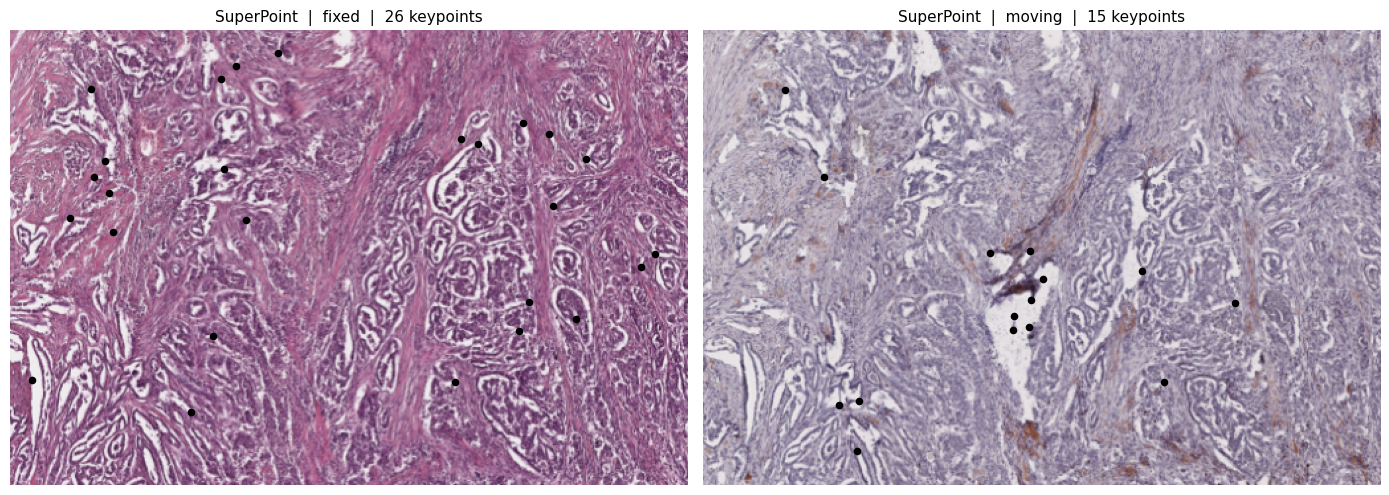

Pair index 0  |  pair_id=0  |  source=6036 → target=6045  |  level=4, grid=16, tile=(7,8)


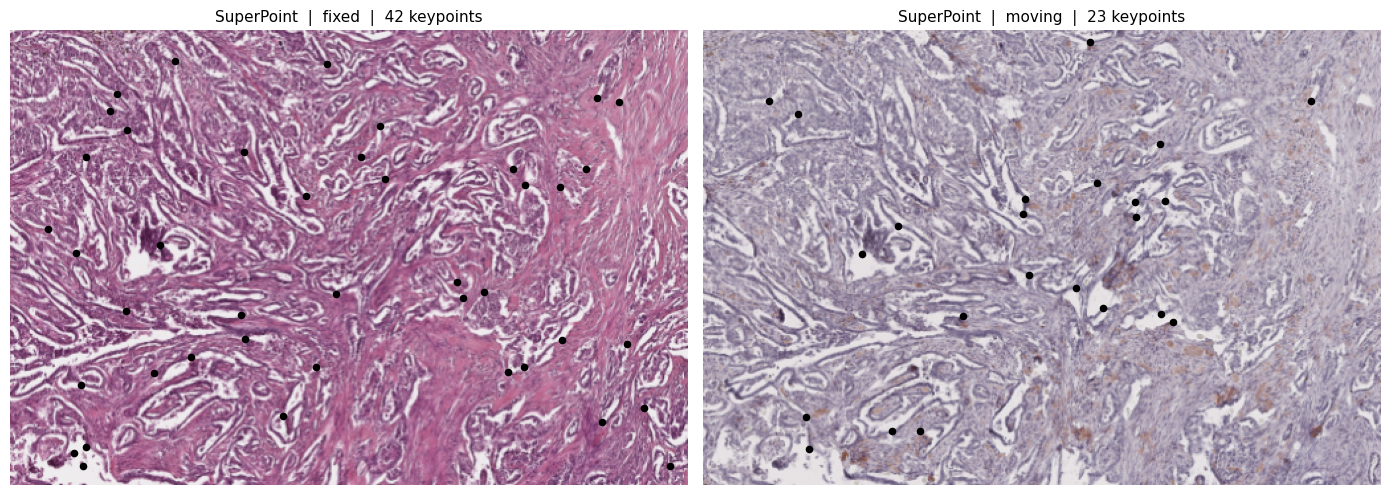

In [29]:
conf_thresh = 0.385

visualize_superpoint(
    pair_id_index=0,
    quadtree_level=4,
    x_idx=8,
    y_idx=8,
    color=True,
    detector=SuperPointDetector(nms_dist=8,
        conf_thresh=conf_thresh,
        nn_thresh=0.7,),
    kp_color="black",
    kp_size=30,
)

visualize_superpoint(
    pair_id_index=0,
    quadtree_level=4,
    x_idx=7,
    y_idx=8,
    color=True,
    detector=SuperPointDetector(nms_dist=8,
        conf_thresh=conf_thresh,
        nn_thresh=0.7,),
    kp_color="black",
    kp_size=30,
)

